# Tier 8 mission verification

Tier 8 follows the architecture's mission ladder:

* **M0** single operating point: the Tier 7 flight point;
* **M1** isolated segments (`mission/segments.py`): hover, climb, cruise, loiter,
  descent, each a flight condition plus a duration, testable on its own;
* **M2** prescribed multi-segment mission (`mission/mission.py`): segments
  chained with fuel burn (mass depletion) and battery state of charge;
* **M3** semi-free mission: cruise speed and every segment's electric power
  fraction become Opti variables, solved for minimum fuel.

Fuel is now a mass item (tank at the common rotor station, so burn does not move
the CG). `examples/mission_analysis.py` closes take-off mass, fuel load
(1.1 x mission fuel) and wing position with the mission on a fixed aircraft
(Tier 6 tails, reference series-hybrid ratings), with SOC >= 0.3 at landing and
every segment's operating margins >= 0.

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier8_missions
```

In [1]:
import ast
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.mission.mission import Mission, build_mission
from aircraft_closure.mission.segments import (ClimbSegment, CruiseSegment, DescentSegment, HoverSegment,
                                               LoiterSegment, ground_distance_m)
from examples.aircraft_mass_closure import build_reference_aircraft
from examples.mission_analysis import (fuel_factor, reference_mission, soc_minimum, solve_mission,
                                       solve_prescribed_mission, solve_semi_free_mission)

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


aircraft = build_reference_aircraft(3.23, area_horizontal_tail_m2=2.16, area_vertical_tail_m2=1.92)
aero = SimpleAerodynamics()
battery = aircraft.powertrain.topology.instances["battery"].component
ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})


def fly(segments, mass_kg=1550.0, soc=0.9):
    opti = asb.Opti()
    flown = build_mission(opti, aircraft, aero, Mission(tuple(segments)), mass_kg, soc)
    opti.minimize(flown.mass_fuel_burnt_kg)
    return flown, opti.solve(verbose=False)

## 1. M1: isolated segments

Each segment is verified on its own: duration, ground distance, the fuel
identity (flow x time), the battery identity (SOC drop = chemical energy /
capacity, including Joule losses) and the hover/airplane mapping.

In [2]:
check("segment: climb duration = delta h / rate", ClimbSegment(0, 1000, 4.0).duration_s() == 250.0)
check("segment: cruise duration = distance / V", CruiseSegment(90000.0, velocity_m_s=60.0).duration_s() == 1500.0)
check("segment: descent evaluated at mean altitude with negative climb rate",
      DescentSegment(1000, 200, 2.0).flight_condition(0.8).altitude_m == 600
      and DescentSegment(1000, 200, 2.0).flight_condition(0.8).climb_rate_m_s == -2.0)
check("segment: climb ground distance uses the horizontal speed",
      close(float(ground_distance_m(ClimbSegment(0, 1000, 3.0, 50.0))), np.sqrt(50.0**2 - 9) * 1000 / 3))

flown, s = fly([CruiseSegment(60000.0, 1000.0, 60.0, 0.0)])
seg = flown.segments[0]
check("cruise: fuel = fuel flow x distance / V", close(float(s.value(seg.mass_fuel_burnt_kg)),
                                                       float(s.value(seg.point.fuel_flow_kg_s)) * 1000.0))
check("cruise: turbo-only segment leaves SOC unchanged", close(float(s.value(seg.soc_end)), 0.9))
flown, s = fly([HoverSegment(60.0, 0.0, 1.0)])
seg = flown.segments[0]
check("hover: SOC drop = chemical energy / capacity",
      close(0.9 - float(s.value(seg.soc_end)), float(s.value(seg.energy_battery_chemical_J)) / battery.energy_capacity_J))
check("hover: chemical energy exceeds terminal energy (Joule losses)",
      float(s.value(seg.energy_battery_chemical_J)) > float(s.value(seg.energy_battery_terminal_J)))
check("hover: all-electric hover burns only generator no-load fuel",
      float(s.value(seg.mass_fuel_burnt_kg)) < 0.05)

PASS  segment: climb duration = delta h / rate
PASS  segment: cruise duration = distance / V
PASS  segment: descent evaluated at mean altitude with negative climb rate
PASS  segment: climb ground distance uses the horizontal speed
PASS  cruise: fuel = fuel flow x distance / V
PASS  cruise: turbo-only segment leaves SOC unchanged
PASS  hover: SOC drop = chemical energy / capacity
PASS  hover: chemical energy exceeds terminal energy (Joule losses)
PASS  hover: all-electric hover burns only generator no-load fuel


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


## 2. M2: prescribed mission

Hover at 70 % battery power; every other segment on the turbogenerator; all
speeds fixed. Take-off mass, fuel load and wing position close with the mission
in one solve.

In [3]:
prescribed = solve_prescribed_mission()
print(f"MTOM {prescribed.mass_takeoff_kg:.1f} kg, fuel load {prescribed.mass_fuel_kg:.2f} kg "
      f"(burnt {prescribed.mass_fuel_burnt_kg:.2f} kg), SOC at landing {prescribed.soc_end:.3f}, "
      f"time {prescribed.duration_s / 60:.1f} min")
for label, duration, fuel, energy, soc, h_e, shaft in prescribed.segments:
    print(f"  {label:<15}{duration:7.0f} s {fuel:7.2f} kg {energy / 3.6e6:6.2f} kWh  SOC {soc:.3f}  h_e {h_e:.2f}  "
          f"{shaft / 1e3:5.1f} kW/rotor")
check("M2: fuel load = 1.1 x burnt fuel", close(prescribed.mass_fuel_kg, fuel_factor * prescribed.mass_fuel_burnt_kg, rel=1e-8))
check("M2: battery used only in hover", all(abs(e) < 1e-3 for l, _, _, e, _, _, _ in prescribed.segments if "hover" not in l))
check("M2: every segment margin non-negative", prescribed.min_margin > -1e-6)
check("M2: total time is the sum of segment durations",
      close(prescribed.duration_s, 60 + 250 + 100000 / 60 + 1200 + 1000 / 3 + 60))
check("M2: cruise burns the most fuel", max(prescribed.segments, key=lambda r: r[2])[0] == "cruise")

MTOM 1588.4 kg, fuel load 31.97 kg (burnt 29.07 kg), SOC at landing 0.798, time 59.5 min
  take-off hover      60 s    0.40 kg   3.09 kWh  SOC 0.873  h_e 0.70   61.4 kW/rotor
  climb              250 s    3.54 kg   0.00 kWh  SOC 0.873  h_e 0.00   40.4 kW/rotor
  cruise            1667 s   15.59 kg   0.00 kWh  SOC 0.873  h_e 0.00   26.2 kW/rotor
  loiter            1200 s    8.29 kg  -0.00 kWh  SOC 0.873  h_e 0.00   18.9 kW/rotor
  descent            333 s    0.85 kg   0.00 kWh  SOC 0.873  h_e 0.00    5.8 kW/rotor
  landing hover       60 s    0.39 kg   3.00 kWh  SOC 0.798  h_e 0.70   59.7 kW/rotor
PASS  M2: fuel load = 1.1 x burnt fuel
PASS  M2: battery used only in hover
PASS  M2: every segment margin non-negative
PASS  M2: total time is the sum of segment durations
PASS  M2: cruise burns the most fuel


## 3. M3: semi-free mission (minimum fuel)

Cruise speed (40-85 m/s) and every segment's electric power fraction are free.
The optimizer slows cruise toward the minimum-fuel speed and spends the battery
down to its SOC floor. Turboshaft efficiency is constant at this tier, so the
fuel saving comes from replacing turbogenerator energy with stored energy, and
from speed.

MTOM 1580.7 kg, fuel load 24.97 kg, SOC at landing 0.300, cruise 51.7 m/s
PASS  M3: less fuel than the prescribed mission
PASS  M3: battery spent to the SOC floor
PASS  M3: lighter take-off (less fuel carried)
PASS  M3: margins non-negative


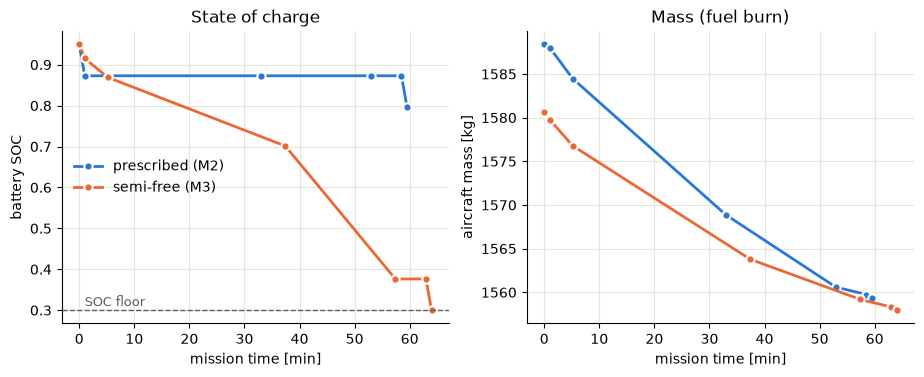

In [4]:
free = solve_semi_free_mission()
print(f"MTOM {free.mass_takeoff_kg:.1f} kg, fuel load {free.mass_fuel_kg:.2f} kg, SOC at landing {free.soc_end:.3f}, "
      f"cruise {free.velocity_cruise_m_s:.1f} m/s")
check("M3: less fuel than the prescribed mission", free.mass_fuel_kg < prescribed.mass_fuel_kg)
check("M3: battery spent to the SOC floor", close(free.soc_end, soc_minimum, rel=1e-6))
check("M3: lighter take-off (less fuel carried)", free.mass_takeoff_kg < prescribed.mass_takeoff_kg)
check("M3: margins non-negative", free.min_margin > -1e-6)

def timeline(result):
    t, soc, mass = [0.0], [0.95], [result.mass_takeoff_kg]
    for label, duration, fuel, energy, soc_end, _, _ in result.segments:
        t.append(t[-1] + duration)
        soc.append(soc_end)
        mass.append(mass[-1] - fuel)
    return np.array(t) / 60, np.array(soc), np.array(mass)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for result, label, color in ((prescribed, "prescribed (M2)", blue), (free, "semi-free (M3)", orange)):
    t, soc, mass = timeline(result)
    ax1.plot(t, soc, color=color, lw=2, marker="o", ms=6, mec="white", mew=1.5, label=label)
    ax2.plot(t, mass, color=color, lw=2, marker="o", ms=6, mec="white", mew=1.5, label=label)
ax1.axhline(soc_minimum, color=ink_muted, lw=1, ls="--")
ax1.text(1, soc_minimum + 0.01, "SOC floor", color=ink_muted, fontsize=9)
ax1.set(xlabel="mission time [min]", ylabel="battery SOC", title="State of charge")
ax2.set(xlabel="mission time [min]", ylabel="aircraft mass [kg]", title="Mass (fuel burn)")
ax1.legend(frameon=False, loc="center left")
plt.show()

mission fuel by cruise speed: {45.0: np.float64(29.01), 50.0: np.float64(28.47), 55.0: np.float64(28.54), 60.0: np.float64(29.07), 70.0: np.float64(31.17), 80.0: np.float64(34.36)}
PASS  speed sweep: an interior minimum-fuel cruise speed exists


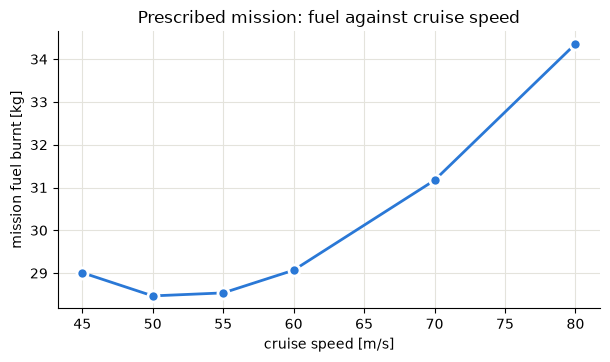

In [5]:
# Fuel per 100 km against a prescribed cruise speed (turbo-only cruise, closed mass).
speeds = [45.0, 50.0, 55.0, 60.0, 70.0, 80.0]
fuel_kg = [solve_mission(reference_mission(velocity_cruise_m_s=v)).mass_fuel_burnt_kg for v in speeds]
best = speeds[int(np.argmin(fuel_kg))]
print("mission fuel by cruise speed:", dict(zip(speeds, np.round(fuel_kg, 2))))
check("speed sweep: an interior minimum-fuel cruise speed exists", speeds[0] < best < speeds[-1])
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(speeds, fuel_kg, color=blue, lw=2, marker="o", ms=8, mec="white", mew=2)
ax.set(xlabel="cruise speed [m/s]", ylabel="mission fuel burnt [kg]", title="Prescribed mission: fuel against cruise speed")
plt.show()

## 4. Boundaries

Missions are orchestration above the flight point: lower layers never import
`mission`, and the mission module adds only its segment physics equalities
(thrust domain); fuel sufficiency, SOC floor and margins are applied by the
caller.

In [6]:
package = repo_root / "src/aircraft_closure"
for layer in ("core", "powertrain", "vehicle", "aerodynamics", "controls", "performance", "requirements"):
    for path in sorted((package / layer).rglob("*.py")):
        tree = ast.parse(path.read_text(encoding="utf-8"))
        imports = {n.module or "" for n in ast.walk(tree) if isinstance(n, ast.ImportFrom)}
        check(f"boundaries: {path.relative_to(package).as_posix()} does not import mission",
              not any("mission" in m for m in imports))
tree = ast.parse((package / "mission/mission.py").read_text(encoding="utf-8"))
used = {n.attr for n in ast.walk(tree) if isinstance(n, ast.Attribute)}
check("boundaries: mission module never minimizes or solves", not used & {"minimize", "solve"})

PASS  boundaries: core/__init__.py does not import mission
PASS  boundaries: core/margins.py does not import mission
PASS  boundaries: core/ports.py does not import mission
PASS  boundaries: core/topology.py does not import mission
PASS  boundaries: powertrain/__init__.py does not import mission
PASS  boundaries: powertrain/compatibility.py does not import mission
PASS  boundaries: powertrain/components/__init__.py does not import mission
PASS  boundaries: powertrain/components/battery.py does not import mission
PASS  boundaries: powertrain/components/gearbox.py does not import mission
PASS  boundaries: powertrain/components/generator.py does not import mission
PASS  boundaries: powertrain/components/motor.py does not import mission
PASS  boundaries: powertrain/components/propulsor.py does not import mission
PASS  boundaries: powertrain/components/rotor.py does not import mission
PASS  boundaries: powertrain/components/turboshaft.py does not import mission
PASS  boundaries: powertrain/

PASS  boundaries: vehicle/fuselage.py does not import mission
PASS  boundaries: vehicle/items.py does not import mission
PASS  boundaries: vehicle/powertrain_installation.py does not import mission
PASS  boundaries: vehicle/surfaces.py does not import mission
PASS  boundaries: aerodynamics/__init__.py does not import mission
PASS  boundaries: aerodynamics/simple.py does not import mission
PASS  boundaries: controls/__init__.py does not import mission
PASS  boundaries: controls/stability.py does not import mission
PASS  boundaries: performance/__init__.py does not import mission
PASS  boundaries: performance/flight_point.py does not import mission
PASS  boundaries: requirements/__init__.py does not import mission
PASS  boundaries: requirements/capability.py does not import mission
PASS  boundaries: mission module never minimizes or solves


## 5. Summary and unit test suite

In [7]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

52 / 52 notebook checks passed


In [8]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 276 tests in 55.091s

OK
